In [1]:
from collections import defaultdict
import json
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

In [2]:
# Load data
folder_path_cold = "../results/cold/staghunt/"
folder_path_ir = "../results/identity_reveal/staghunt/"

def load_data(folder_path):
    data = []
    for root, dirs, files in os.walk(folder_path):
        for filename in files:
            if filename.endswith(".json"):
                file_path = os.path.join(root, filename)
                try:
                    with open(file_path, "r") as f:
                        entry = json.load(f)
                        data.append(entry)
                except json.JSONDecodeError as e:
                    print(f"Skipped invalid JSON: {file_path} ({e})")
    
    print(f"Loaded {len(data)} valid JSON result files from '{folder_path}' and its subfolders.")
    return data

data_cold = load_data(folder_path_cold)
data_ir = load_data(folder_path_ir)

Loaded 477 valid JSON result files from '../results/cold/staghunt/' and its subfolders.
Loaded 444 valid JSON result files from '../results/identity_reveal/staghunt/' and its subfolders.


In [3]:
def unordered_pair(a, b):
    return tuple(sorted([a, b]))

def process(data):
    aggregates = defaultdict(lambda: {
        "model_0": None,
        "model_1": None,
        "rewards": {0: [], 1: []},
        "cooperation": {0: [], 1: []},
    })
    
    # Aggregate data
    for entry in data:
        m0 = entry["model_general_name_0"]
        m1 = entry["model_general_name_1"]
        pair = unordered_pair(m0, m1)
    
        rewards = [entry["agent_0_reward"], entry["agent_1_reward"]]
        actions = [
            1 if entry["agent_0_answer"]["action"] == "A" else 0,
            1 if entry["agent_1_answer"]["action"] == "A" else 0
        ]
    
        # Flip role if needed
        if pair == (m0, m1):
            idx_0, idx_1 = 0, 1
        else:
            idx_0, idx_1 = 1, 0
    
        aggregates[pair]["model_0"] = pair[0]
        aggregates[pair]["model_1"] = pair[1]
        aggregates[pair]["rewards"][0].append(rewards[idx_0])
        aggregates[pair]["rewards"][1].append(rewards[idx_1])
        aggregates[pair]["cooperation"][0].append(actions[idx_0])
        aggregates[pair]["cooperation"][1].append(actions[idx_1])
    
    # Convert to row list
    rows = []
    for (m0, m1), stats in aggregates.items():
        def compute_stats(i):
            r = stats["rewards"][i]
            c = stats["cooperation"][i]
            return sum(r) / len(r), sum(c) / len(c) * 100
    
        avg_r0, coop_0 = compute_stats(0)
        avg_r1, coop_1 = compute_stats(1)
    
        rows.append({
            "model_0": m0,
            "model_1": m1,
            "avg_reward_0": avg_r0,
            "avg_reward_1": avg_r1,
            "cooperation_%_0": coop_0,
            "cooperation_%_1": coop_1,
            "n_matches": len(stats["rewards"][0])
        })
    
    df_coop_summary = pd.DataFrame(rows)
    # return df_coop_summary.sort_values(["model_0", "model_1"], inplace=True)
    return df_coop_summary

df_cold = process(data_cold)
print(df_cold)
df_ir = process(data_ir)
print(df_ir)

    model_0   model_1  avg_reward_0  avg_reward_1  cooperation_%_0  \
0    claude    claude     10.000000     10.000000       100.000000   
1    claude  deepseek      9.000000      7.366667        70.000000   
2    claude       gpt      8.627119      9.694915       100.000000   
3    claude   mistral      5.766667      7.516667        78.333333   
4  deepseek  deepseek      9.448276      9.448276        93.103448   
5  deepseek       gpt      5.200000      7.883333        85.000000   
6  deepseek   mistral      9.610169      8.898305        88.135593   
7       gpt       gpt      6.733333      6.500000        36.666667   
8       gpt   mistral      9.366667      8.083333        78.333333   
9   mistral   mistral      8.533333      9.000000        86.666667   

   cooperation_%_1  n_matches  
0       100.000000         30  
1        93.333333         60  
2        84.745763         59  
3        53.333333         60  
4        93.103448         29  
5        46.666667         60  
6    

In [4]:
def show_results(df_coop_summary):
    # Step 1: Create long-form data for all pair directions
    rows_long = []
    
    for _, row in df_coop_summary.iterrows():
        rows_long.append({
            "model_a": row["model_0"],
            "model_b": row["model_1"],
            "cooperation_percent": row["cooperation_%_0"]
        })
        rows_long.append({
            "model_a": row["model_1"],
            "model_b": row["model_0"],
            "cooperation_percent": row["cooperation_%_1"]
        })
    
    df_long = pd.DataFrame(rows_long)
    
    # Step 2: Pivot to matrix form
    heatmap_df = df_long.pivot_table(
        index="model_a",
        columns="model_b",
        values="cooperation_percent",
        aggfunc="mean"
    )
    
    # Step 3: Plot
    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_df, annot=True, fmt=".1f", cmap="Blues", cbar_kws={'label': 'Cooperation %'}, vmin=0, vmax=100.0,)
    plt.title("Cooperation % by Model Pair")
    plt.ylabel("Cooperator")
    plt.xlabel("Cooperatee")
    plt.tight_layout()
    # plt.savefig("4.5-staghunt.eps", dpi=300, bbox_inches='tight')
    plt.show()

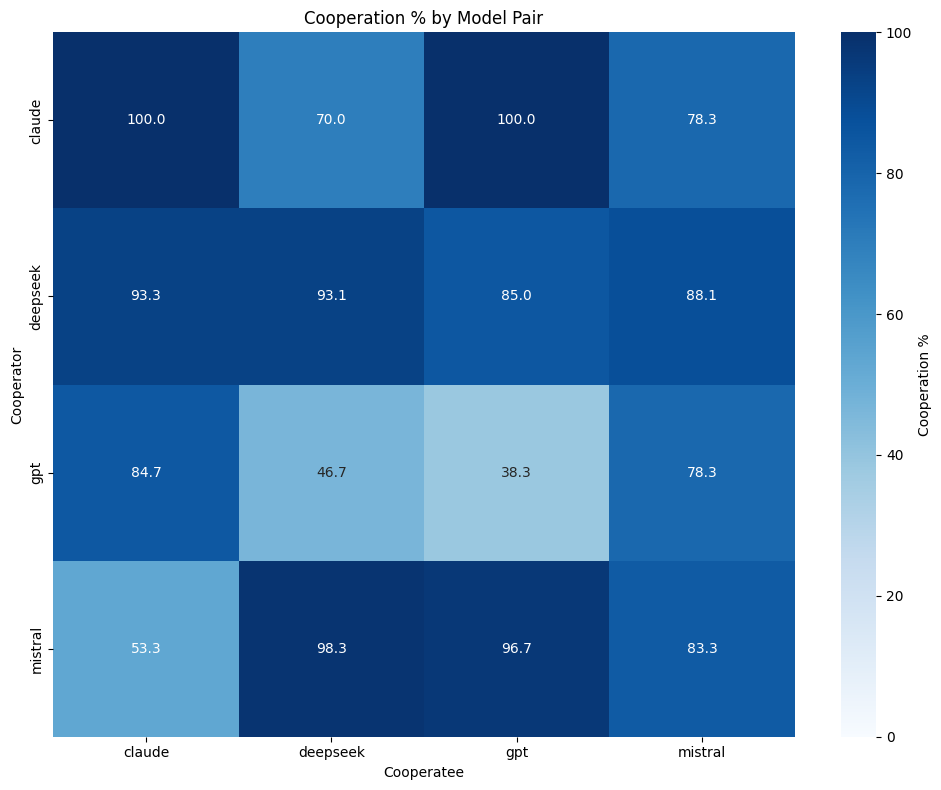

In [5]:
show_results(df_cold)

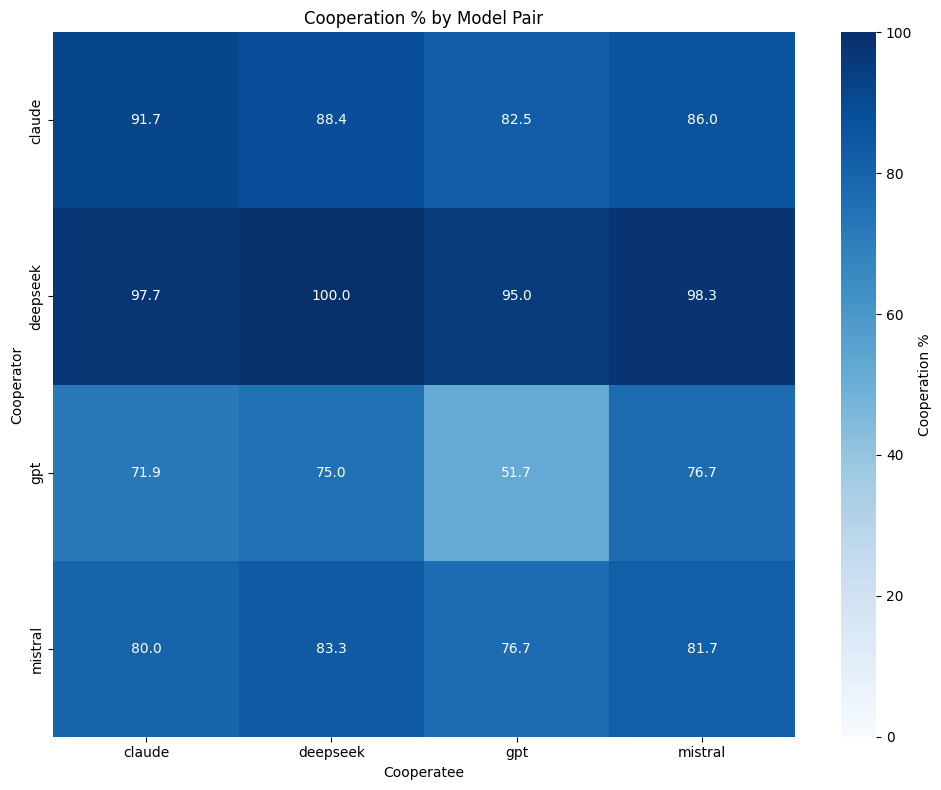

In [6]:
show_results(df_ir)